ENERGY FORECASTING AND TIME SERIES ANALYSIS OF INDIVIDUAL HOUSEHOLDS IN SCEAUX

IMPORTING DATASET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [2]:
data = pd.read_csv("household_power_consumption.txt",sep=';')
df = pd.DataFrame(data)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22076\1420178408.py:1: DtypeWarning: Columns (0: Global_active_power, 1: Global_reactive_power, 2: Voltage, 3: Global_intensity, 4: Sub_metering_1, 5: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("household_power_consumption.txt",sep=';')


DATA CLEANING

In [3]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [8]:
df.shape

(2075259, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(6), str(2)
memory usage: 142.5+ MB


In [5]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [7]:
df['Sub_metering_3'] = pd.to_numeric(df['Sub_metering_3'], errors='coerce')
sub3_mean = df['Sub_metering_3'].mean()
df['Sub_metering_3'] = df['Sub_metering_3'].fillna(sub3_mean)
df['Sub_metering_3'].isnull().sum()

np.int64(0)

In [9]:
columns_to_convert = [
    'Global_active_power', 'Global_reactive_power',
    'Voltage','Global_intensity','Sub_metering_1','Sub_metering_2'
]

for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors ='coerce' )

In [10]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.075259e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.384178e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [11]:
df['dt_string'] = df['Date']+ ' ' + df['Time']
df['dt'] = pd.to_datetime(df['dt_string'], dayfirst=True)
df.set_index('dt', inplace = True)
df.drop(['Date','Time','dt_string'], axis=1, inplace=True)
print(df.head())

                     Global_active_power  Global_reactive_power  Voltage  \
dt                                                                         
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
dt                                                                      
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 17:28:00          

In [12]:
def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['lag_1h'] = df['Global_active_power'].shift(1)
    df['lag_24h'] = df['Global_active_power'].shift(24)
    return df


In [13]:
df_feature = create_features(df)

DATA VISUALIZATION

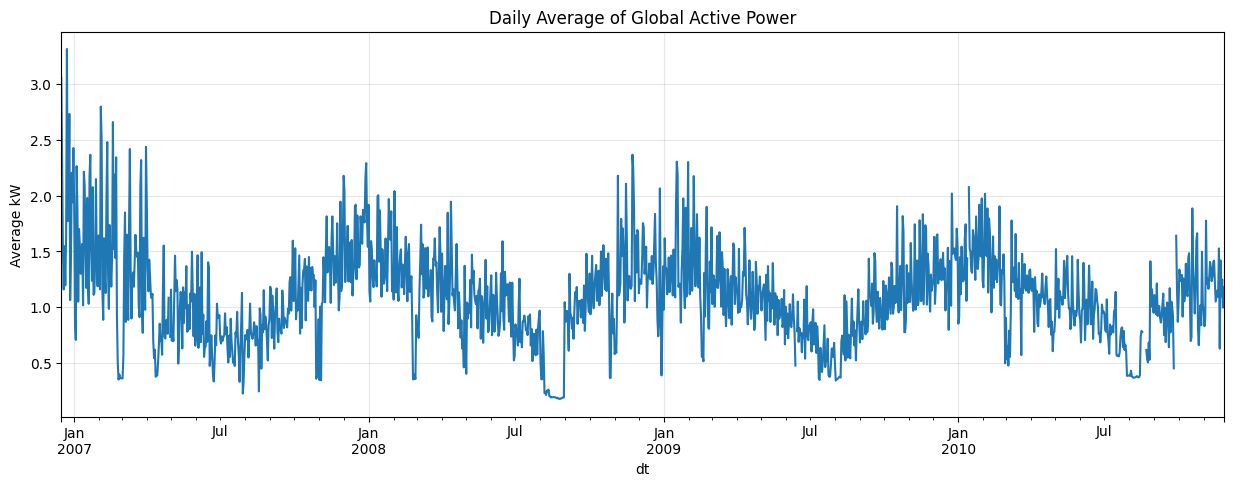

In [14]:
df['Global_active_power'].resample('D').mean().plot(figsize=(15,5))
plt.title("Daily Average of Global Active Power")
plt.ylabel("Average kW")
plt.grid(alpha = 0.3)
plt.show()

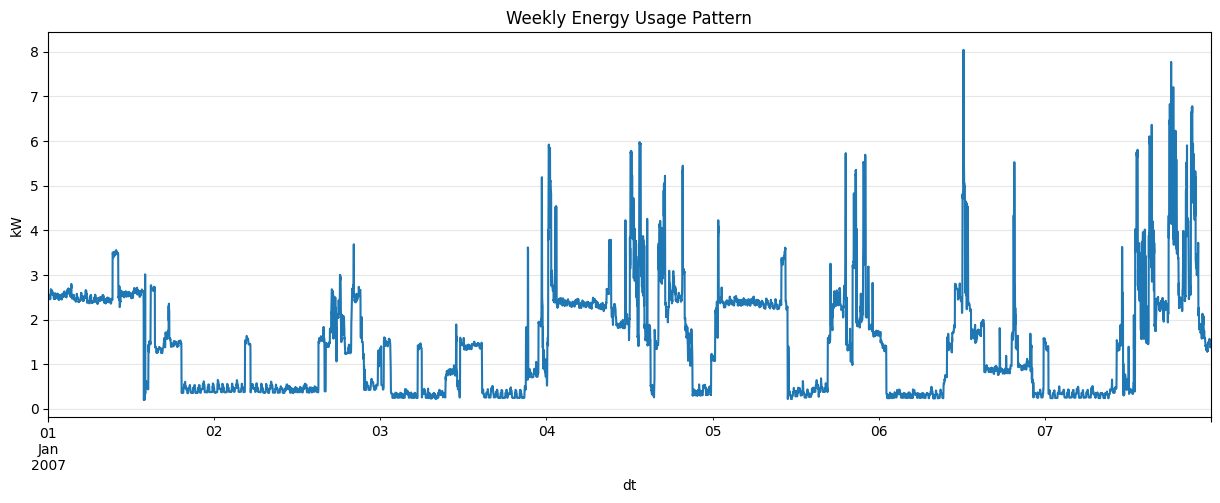

In [15]:
one_week = df['2007-01-01':'2007-01-07']
one_week['Global_active_power'].plot(figsize=(15,5))
plt.title("Weekly Energy Usage Pattern")
plt.ylabel("kW")
plt.grid(alpha=0.3)
plt.show()

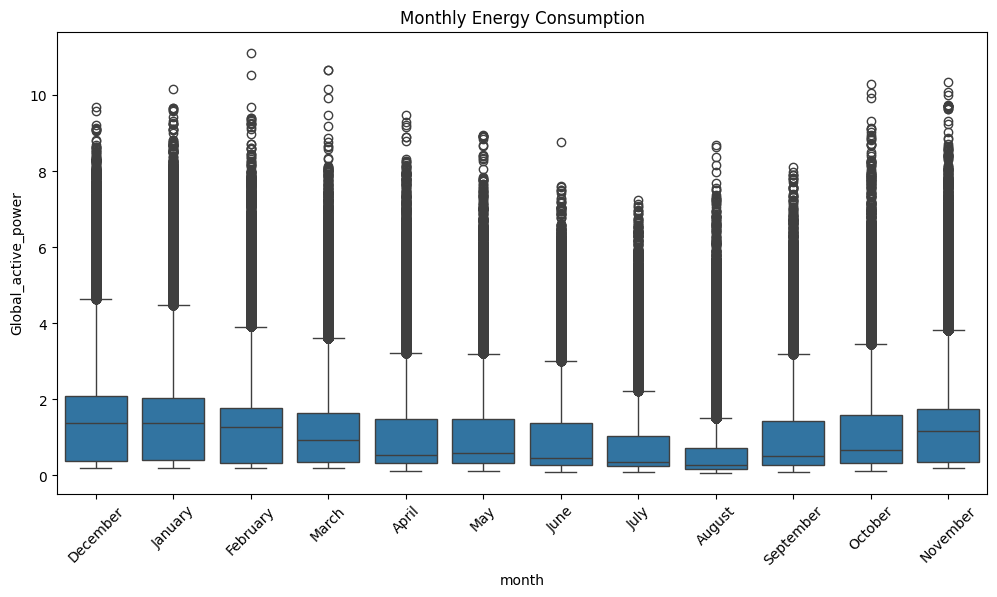

In [16]:
df['month']=df.index.month_name()
df_sample = df.sample(frac=0.1)
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='month', y='Global_active_power',)
plt.title("Monthly Energy Consumption")
plt.xticks(rotation=45)
plt.show()

DATA MODELLING

In [17]:
split_date = '2010-01-01'
train_data = df_feature.loc[df_feature.index<split_date]
test_data = df_feature.loc[df_feature.index>=split_date]

In [18]:
features = ['hour', 'dayofweek', 'quarter', 'month', 'year', 'lag_1h', 'lag_24h']
X_train = train_data[features]
y_train = train_data['Global_active_power']

X_test = test_data[features]
y_test = test_data['Global_active_power']

y_train = pd.to_numeric(y_train, errors='coerce').fillna(0)
y_test = pd.to_numeric(y_test, errors='coerce').fillna(0)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

X_train: (1600236, 7), y_train: (1600236,)


In [19]:
model = XGBRegressor(n_estimators = 5000, early_stopping_rounds = 50, learning_rate = 0.05)

In [20]:
model.fit(X_train, y_train,
          eval_set = [(X_test, y_test)],
          verbose = 100)

[0]	validation_0-rmse:0.89549
[100]	validation_0-rmse:0.24889
[107]	validation_0-rmse:0.24902


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [21]:
predictions = model.predict(X_test)

MODEL EVALUATION

In [23]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: {mae:.2f} kW")
print(f"Root Mean Squared Error: {rmse:.2f} kW")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 0.11 kW
Root Mean Squared Error: 0.24 kW
R2 Score: 0.93


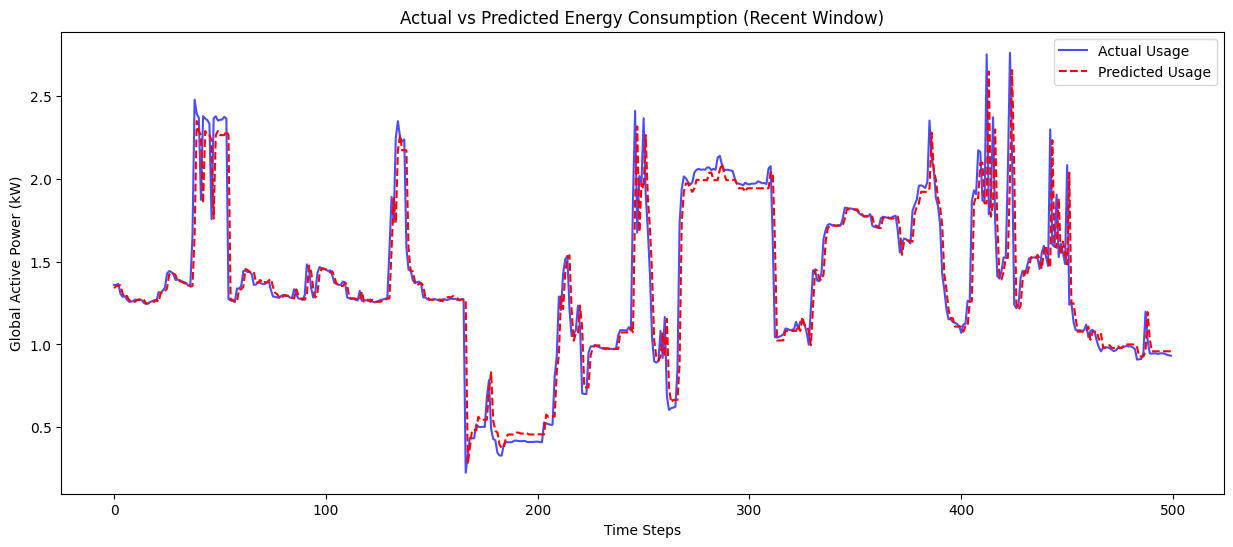

In [24]:
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[-500:], label='Actual Usage', color='blue', alpha=0.7)
plt.plot(predictions[-500:], label='Predicted Usage', color='red', linestyle='--')
plt.title('Actual vs Predicted Energy Consumption (Recent Window)')
plt.xlabel('Time Steps')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.show()

RESIDUAL

In [25]:
results = pd.DataFrame(index=X_test.index)
results['Actual'] = y_test
results['Predicted'] = predictions
results['Residual'] = results['Actual'] - results['Predicted']
print(results['Residual'].describe())

count    475023.000000
mean         -0.014673
std           0.240264
min          -3.417059
25%          -0.052941
50%          -0.041334
75%           0.010558
max           3.832705
Name: Residual, dtype: float64


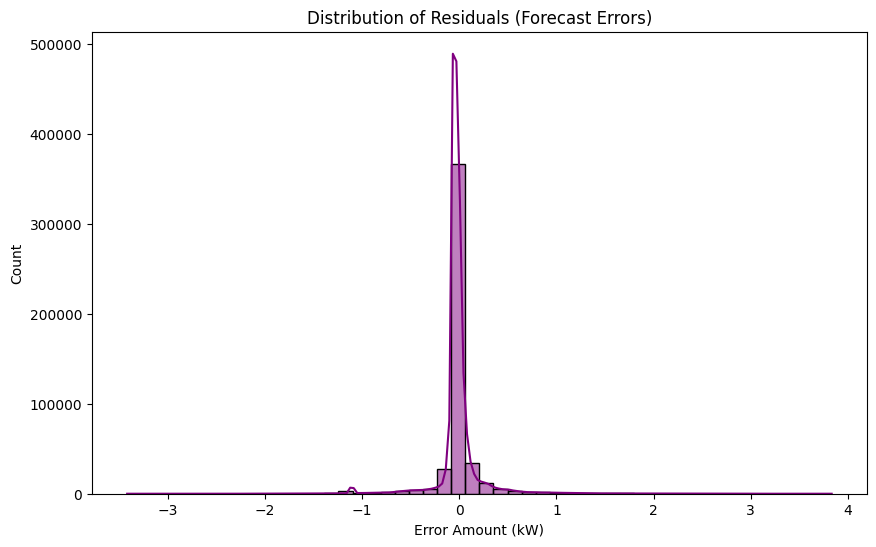

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(results['Residual'], bins=50, kde=True, color='purple')
plt.title('Distribution of Residuals (Forecast Errors)')
plt.xlabel('Error Amount (kW)')
plt.show()

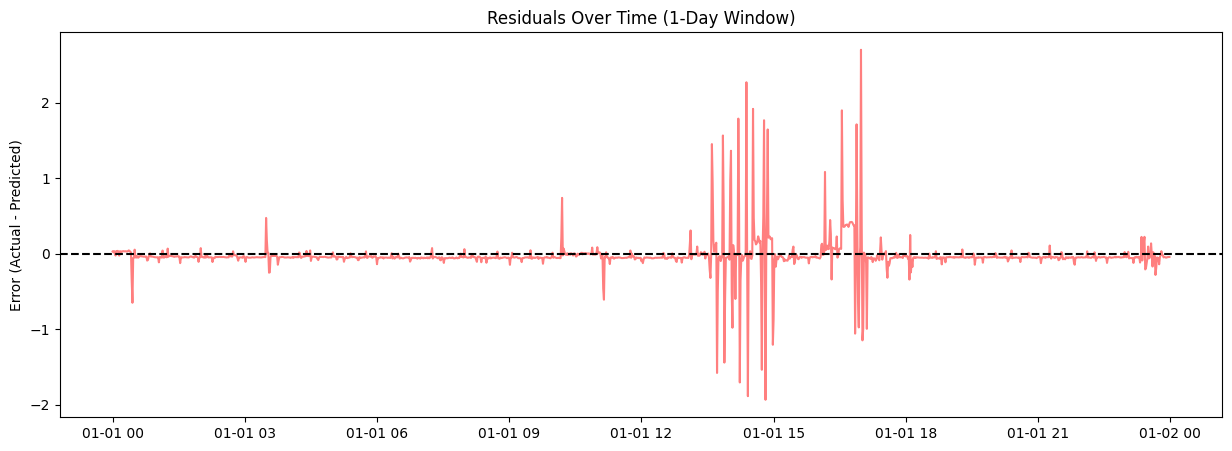

In [27]:
plt.figure(figsize=(15, 5))
plt.plot(results['Residual'].iloc[:1440], color='red', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--') # The "Perfect Prediction" line
plt.title('Residuals Over Time (1-Day Window)')
plt.ylabel('Error (Actual - Predicted)')
plt.show()